# Sorcha ROC Comparison — VDP vs digest2

Head-to-head comparison of the VDP probability-map classifier vs digest2 on 598,670 tracklets
from the Sorcha-based Rubin/NEOCP simulation.

Tracklets scored with all 5 VDP maps (nearest-map assignment); digest2 run on a stratified
subsample of all 98,646 NEO tracklets + 500K proportionally-sampled non-NEOs.

**Section 13** repeats the ROC on epoch-matched tracklets only (observations within ±30 days
of their assigned map's epoch), which isolates the VDP's performance when the solar-elongation
geometry actually matches the map.

Pre-computed scores are in `outputs/phase2/sorcha_comparison.parquet`.


In [1]:
# Optional: re-run the full pipeline from this notebook (slow)
# The script now chunks digest2 calls, so the full run can take about an hour.
# %run run_digest2_comparison.py


## 1. Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

_HERE = os.path.abspath('.')
PARQUET = os.path.join(_HERE, 'outputs/phase2/sorcha_comparison.parquet')
FIG_OUT = os.path.join(_HERE, 'outputs/phase2/roc_comparison_sorcha.png')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})


## 2. Load results

In [ ]:
df = pd.read_parquet(PARQUET)
print(f'{len(df):,} tracklets')
print(df['population'].value_counts().to_string())

pops = ['NEO', 'MBA', 'Trojan', 'TNO', 'other']
colors = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green',
          'Trojan': 'tab:red', 'other': 'tab:purple'}
df.head()


## 3. Score distributions

/tmp/ipykernel_4075487/617390745.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/mmfs1/gscratch/astro/ds2004/sorcha/conda_prep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


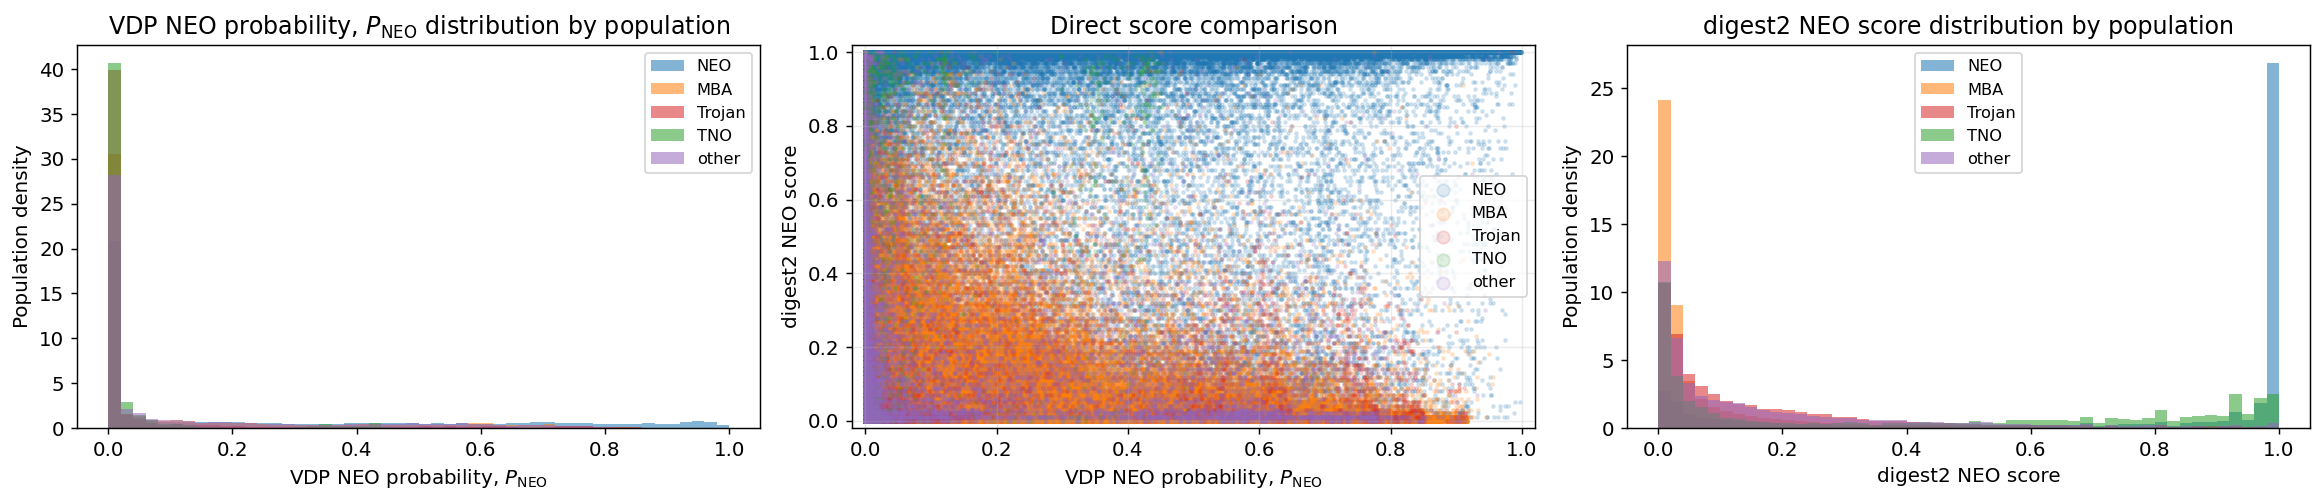

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hist_specs = [
    (axes[0], 'P_NEO_vdp', 'VDP NEO probability, $P_{\mathrm{NEO}}$'),
    (axes[2], 'P_NEO_d2',  'digest2 NEO score'),
]

for ax, col, label in hist_specs:
    for pop in pops:
        sub = df.loc[df.population == pop, col]
        ax.hist(sub, bins=50, alpha=0.55, label=pop, color=colors.get(pop),
                density=True, range=(0, 1))
    ax.set_xlabel(label)
    ax.set_ylabel('Population density')
    ax.set_title(f'{label} distribution by population')
    ax.legend(fontsize=9)

ax = axes[1]
for pop in pops:
    sub = df[df.population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('Direct score comparison')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=9, markerscale=4)

plt.tight_layout()
plt.show()
plt.close(fig)


## 4. ROC curves

In [ ]:
is_neo = (df['population'] == 'NEO').to_numpy()
N_neo  = is_neo.sum()
N_non  = (~is_neo).sum()
print(f'N_NEO={N_neo:,}  N_non-NEO={N_non:,}')

thresholds = np.linspace(0, 1, 401)

def compute_roc(scores, is_neo, thresholds):
    """Sweep thresholds; uses is_neo.sum() as denominator (self-contained)."""
    N_pos = is_neo.sum()
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))
    for j, t in enumerate(thresholds):
        above = scores > t
        tp = above[is_neo].sum()
        fp = above[~is_neo].sum()
        comp[j] = tp / max(N_pos, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont

def best_f1(comp, cont, thr):
    pur = 1 - cont
    f1  = np.where(pur + comp > 0, 2*pur*comp/(pur + comp + 1e-12), 0.0)
    i   = np.argmax(f1)
    return thr[i], comp[i], cont[i], f1[i]

comp_v, cont_v = compute_roc(df['P_NEO_vdp'].to_numpy(), is_neo, thresholds)
comp_d, cont_d = compute_roc(df['P_NEO_d2'].to_numpy(),  is_neo, thresholds)

tv, cv, nv, fv = best_f1(comp_v, cont_v, thresholds)
td, cd, nd, fd = best_f1(comp_d, cont_d, thresholds)

print(f'VDP     best: t={tv:.3f}  completeness={cv:.1%}  contamination={nv:.1%}  F1={fv:.3f}')
print(f'Digest2 best: t={td:.3f}  completeness={cd:.1%}  contamination={nd:.1%}  F1={fd:.3f}')


Saved: /mmfs1/gscratch/astro/ds2004/sorcha/outputs/phase2/roc_comparison_wagg_sorcha.png


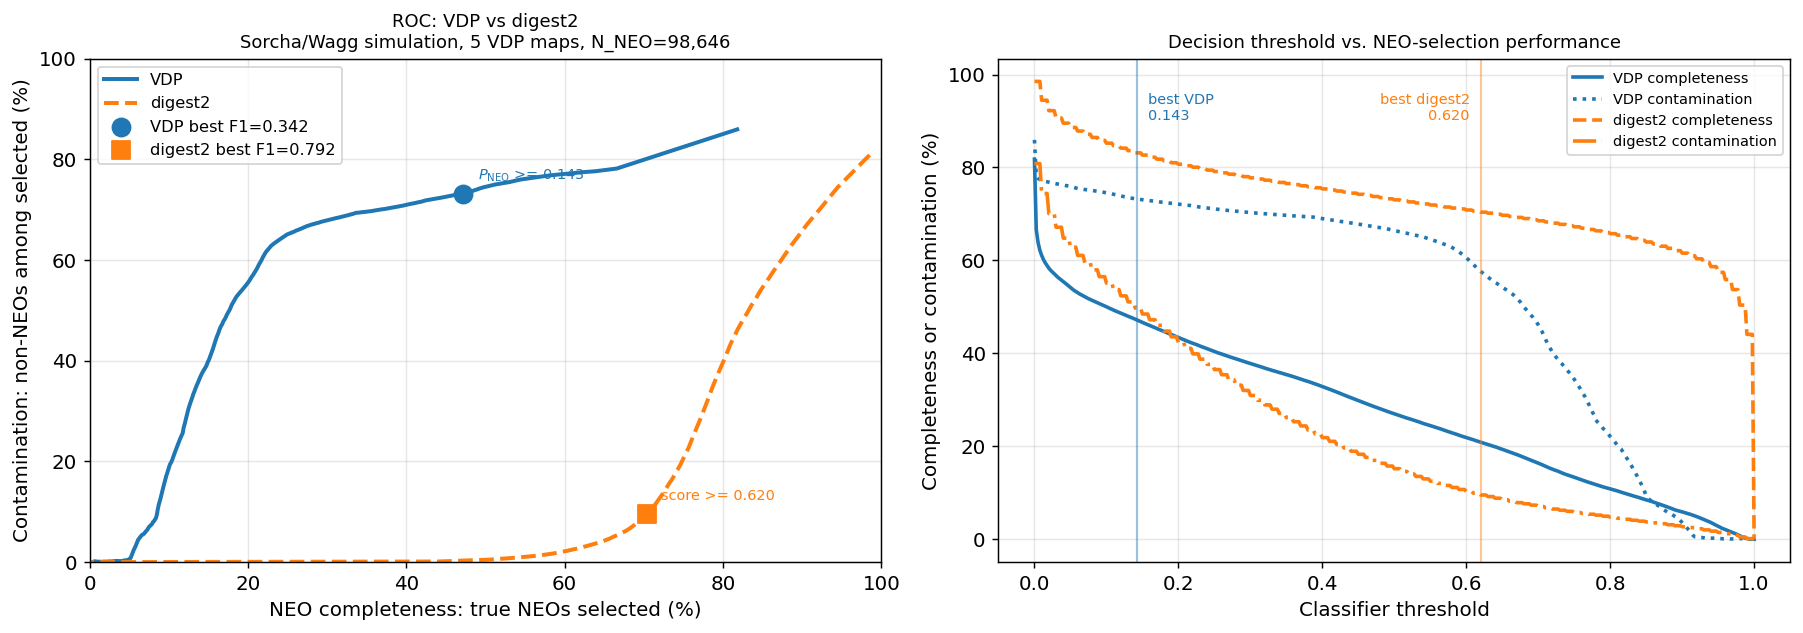

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(comp_v*100, cont_v*100, lw=2.2, color='tab:blue', label='VDP')
ax.plot(comp_d*100, cont_d*100, lw=2.2, color='tab:orange', linestyle='--', label='digest2')
ax.scatter([cv*100], [nv*100], color='tab:blue', s=100, zorder=5, label=f'VDP best F1={fv:.3f}')
ax.scatter([cd*100], [nd*100], color='tab:orange', s=100, zorder=5, marker='s', label=f'digest2 best F1={fd:.3f}')
ax.annotate(f'$P_{{\mathrm{{NEO}}}}$ >= {tv:.3f}', xy=(cv*100, nv*100), xytext=(8, 8),
            textcoords='offset points', color='tab:blue', fontsize=8)
ax.annotate(f'score >= {td:.3f}', xy=(cd*100, nd*100), xytext=(8, 8),
            textcoords='offset points', color='tab:orange', fontsize=8)
ax.set_xlabel('NEO completeness: true NEOs selected (%)')
ax.set_ylabel('Contamination: non-NEOs among selected (%)')
ax.set_title(f'ROC: VDP vs digest2\nSorcha simulation, 5 VDP maps, N_NEO={N_neo:,}', fontsize=10)
ax.legend(fontsize=9, frameon=True, loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

ax = axes[1]
ax.plot(thresholds, comp_v*100, lw=2, color='tab:blue', label='VDP completeness')
ax.plot(thresholds, cont_v*100, lw=2, color='tab:blue', linestyle=':', label='VDP contamination')
ax.plot(thresholds, comp_d*100, lw=2, color='tab:orange', linestyle='--', label='digest2 completeness')
ax.plot(thresholds, cont_d*100, lw=2, color='tab:orange', linestyle='-.', label='digest2 contamination')
ax.axvline(tv, color='tab:blue', alpha=0.45, lw=1.2)
ax.axvline(td, color='tab:orange', alpha=0.45, lw=1.2)
ax.text(tv + 0.015, 96, f'best VDP\n{tv:.3f}', color='tab:blue', fontsize=8, va='top')
ax.text(td - 0.015, 96, f'best digest2\n{td:.3f}', color='tab:orange', fontsize=8, va='top', ha='right')
ax.set_xlabel('Classifier threshold')
ax.set_ylabel('Completeness or contamination (%)')
ax.set_title('Decision threshold vs. NEO-selection performance', fontsize=10)
ax.legend(fontsize=8, frameon=True, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
print(f'Saved: {FIG_OUT}')
plt.show()
plt.close(fig)


## 5. Score-threshold quadrants

The direct score comparison becomes more useful if we draw the best-F1 decision thresholds from the ROC section. These four quadrants show where VDP and digest2 agree, and where each classifier uniquely selects candidates.

In [ ]:
vdp_selected = df['P_NEO_vdp'] >= tv
d2_selected  = df['P_NEO_d2']  >= td

quadrant_labels = np.select(
    [vdp_selected & d2_selected, vdp_selected & ~d2_selected, ~vdp_selected & d2_selected],
    ['both select', 'VDP only', 'digest2 only'],
    default='neither selects',
)

quad_df = df.assign(score_quadrant=quadrant_labels)
quad_summary = (
    quad_df
    .groupby(['score_quadrant', 'population'])
    .size()
    .unstack(fill_value=0)
    .reindex(['both select', 'VDP only', 'digest2 only', 'neither selects'])
)
quad_summary['total'] = quad_summary.sum(axis=1)
quad_summary['NEO fraction'] = (quad_summary.get('NEO', 0) / quad_summary['total']).map('{:.1%}'.format)
display(quad_summary)

fig, ax = plt.subplots(figsize=(7, 6))
for pop in pops:
    sub = df[df.population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.75)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.75)
ax.text(tv + 0.012, 0.04, f'VDP threshold\n{tv:.3f}', color='tab:blue', fontsize=8)
ax.text(0.04, td - 0.04, f'digest2 threshold {td:.3f}', color='tab:orange', fontsize=8, va='top')
ax.text(0.72, 0.92, 'both select',     transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.72, 0.08, 'VDP only',        transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.92, 'digest2 only',    transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.08, 'neither selects', transform=ax.transAxes, fontsize=9, ha='center')
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('Score-threshold quadrants')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, markerscale=4, loc='center right')
plt.tight_layout()
plt.show()
plt.close(fig)


### Log-log score-threshold quadrants

The linear quadrant plot hides most of the structure near zero. This version uses log-scaled axes and clips exact zero scores to a small plotting floor so low-score objects remain visible.

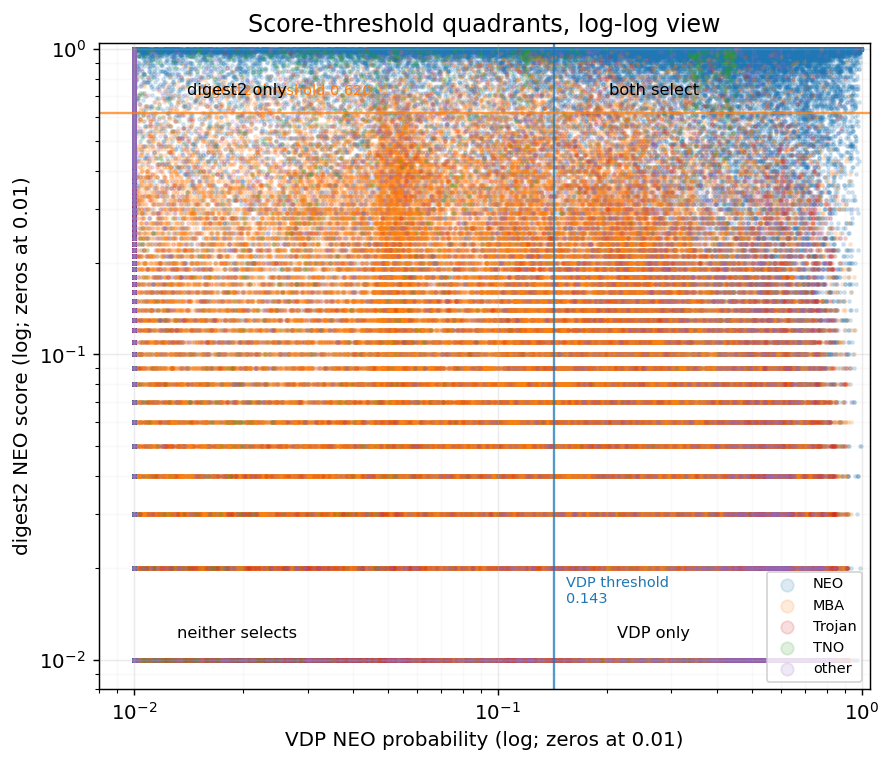

In [15]:
score_floor = 1e-2

x_log = np.clip(df['P_NEO_vdp'].to_numpy(), score_floor, 1.0)
y_log = np.clip(df['P_NEO_d2'].to_numpy(),  score_floor, 1.0)

fig, ax = plt.subplots(figsize=(7, 6))
for pop in pops:
    mask = (df.population == pop).to_numpy()
    ax.scatter(x_log[mask], y_log[mask], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.75)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.75)
ax.text(tv * 1.08, score_floor * 1.5, f'VDP threshold\n{tv:.3f}', color='tab:blue', fontsize=8, va='bottom')
ax.text(score_floor * 1.5, td * 1.12, f'digest2 threshold {td:.3f}', color='tab:orange', fontsize=8, va='bottom')
ax.text(0.72, 0.92, 'both select',     transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.72, 0.08, 'VDP only',        transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.92, 'digest2 only',    transform=ax.transAxes, fontsize=9, ha='center')
ax.text(0.18, 0.08, 'neither selects', transform=ax.transAxes, fontsize=9, ha='center')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(score_floor * 0.8, 1.05); ax.set_ylim(score_floor * 0.8, 1.05)
ax.set_xlabel(f'VDP NEO probability (log; zeros at {score_floor:g})')
ax.set_ylabel(f'digest2 NEO score (log; zeros at {score_floor:g})')
ax.set_title('Score-threshold quadrants, log-log view')
ax.grid(alpha=0.25, which='major'); ax.grid(alpha=0.07, which='minor')
ax.legend(fontsize=8, markerscale=4, loc='lower right')
plt.tight_layout()
plt.show()
plt.close(fig)


### Population-visible square log-log quadrant view

The `1e-2` display floor makes the plot compact but hides the TNO/Trojan structure by clipping too aggressively. This version keeps a lower score floor and plots NEOs first, then the non-NEO populations on top, so the distant-population disagreement region remains visible.

In [1]:
score_floor_visible = 1e-4
x_visible = np.clip(df['P_NEO_vdp'].to_numpy(), score_floor_visible, 1.0)
y_visible = np.clip(df['P_NEO_d2'].to_numpy(),  score_floor_visible, 1.0)

plot_style = {
    'NEO':    dict(s=3, alpha=0.12, zorder=2),
    'MBA':    dict(s=4, alpha=0.20, zorder=3),
    'TNO':    dict(s=5, alpha=0.35, zorder=5),
    'Trojan': dict(s=5, alpha=0.35, zorder=6),
    'other':  dict(s=5, alpha=0.35, zorder=4),
}

fig, ax = plt.subplots(figsize=(7.0, 7.0))
for pop in pops:
    mask = (df.population == pop).to_numpy()
    ax.scatter(x_visible[mask], y_visible[mask], label=pop,
               color=colors.get(pop), rasterized=True, **plot_style[pop])

ax.axvline(tv, color='tab:blue', lw=1.3, alpha=0.85, zorder=8)
ax.axhline(td, color='tab:orange', lw=1.3, alpha=0.85, zorder=8)
ax.axvspan(tv, 1.05, color='tab:blue', alpha=0.03, zorder=0)
ax.axhspan(td, 2.0,  color='tab:orange', alpha=0.045, zorder=0)
ax.text(tv * 1.08, 8e-3 * 1.4, f'VDP threshold\n{tv:.3f}', color='tab:blue', fontsize=8, va='bottom')
ax.text(score_floor_visible * 1.6, td * 1.10, f'digest2 threshold {td:.3f}', color='tab:orange', fontsize=8, va='bottom')
ax.text(0.20, 1.08, 'both select',     fontsize=10, ha='center', va='center')
ax.text(0.08, 0.020,'VDP only',        fontsize=10, ha='center', va='center')
ax.text(8.0e-4, 0.70,'digest2 only',   fontsize=10, ha='center', va='center')
ax.text(8.0e-4, 0.014,'neither',       fontsize=10, ha='center', va='center')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(score_floor_visible, 1.05); ax.set_ylim(8e-3, 2.0)
ax.set_box_aspect(1)
ax.set_xlabel(f'VDP NEO probability (log; floor {score_floor_visible:g})')
ax.set_ylabel(f'digest2 NEO score (log; floor {score_floor_visible:g})')
ax.set_title('Score-threshold quadrants, population-visible log-log view', pad=10)
ax.grid(alpha=0.28, which='major'); ax.grid(alpha=0.07, which='minor')
ax.legend(fontsize=8, markerscale=4, loc='lower right', frameon=True)
plt.tight_layout()
display(fig)
plt.close(fig)


NameError: name 'np' is not defined

## 6. 2D score density

The scatter plot hides the density near zero because many objects overlap. Hexbin views show the same score space as density, first for all objects and then split into true NEO and non-NEO samples.

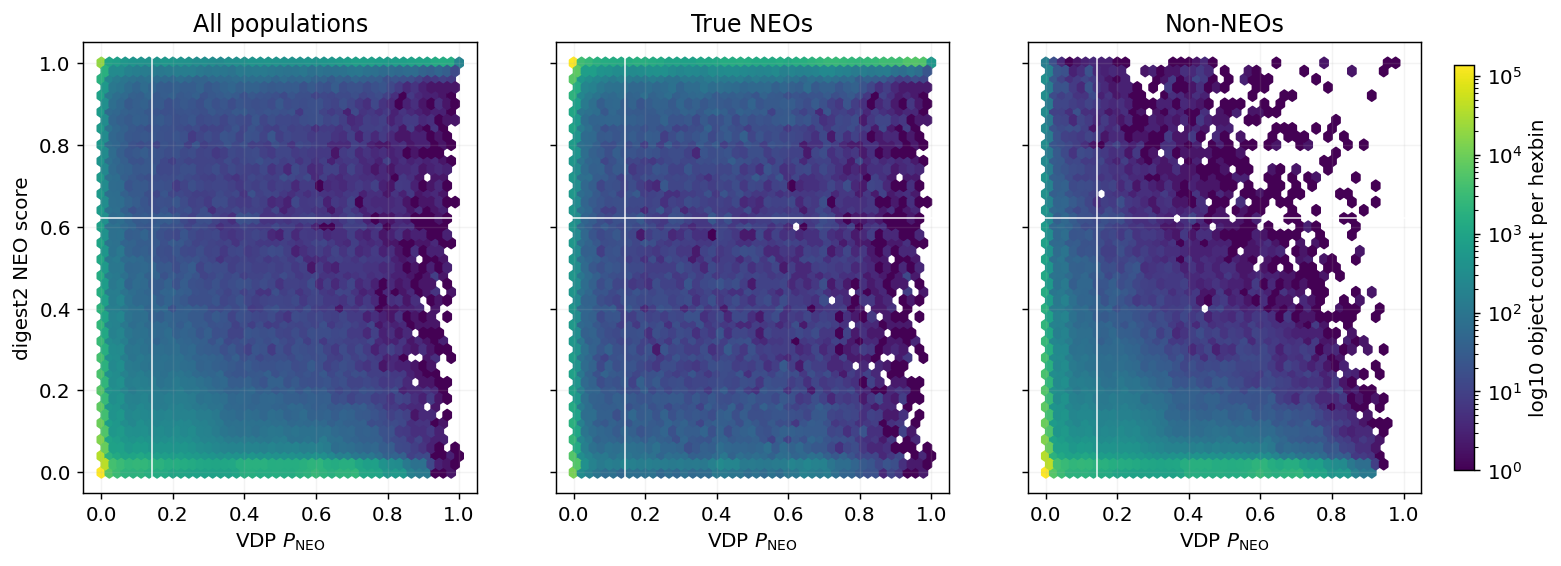

In [7]:
density_views = [
    ('All populations', np.ones(len(df), dtype=bool)),
    ('True NEOs', is_neo),
    ('Non-NEOs', ~is_neo),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, (title, mask) in zip(axes, density_views):
    hb = ax.hexbin(
        df.loc[mask, 'P_NEO_vdp'],
        df.loc[mask, 'P_NEO_d2'],
        gridsize=45,
        extent=(0, 1, 0, 1),
        bins='log',
        mincnt=1,
        cmap='viridis',
    )
    ax.axvline(tv, color='white', lw=1.0, alpha=0.8)
    ax.axhline(td, color='white', lw=1.0, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('VDP $P_{\mathrm{NEO}}$')
    ax.grid(alpha=0.15)
axes[0].set_ylabel('digest2 NEO score')
cbar = fig.colorbar(hb, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label('log10 object count per hexbin')
plt.show()
plt.close(fig)

## 7. Rank comparison

Thresholds are useful, but follow-up is often rank-ordered. This view asks whether the same objects appear near the top of each classifier's candidate list.

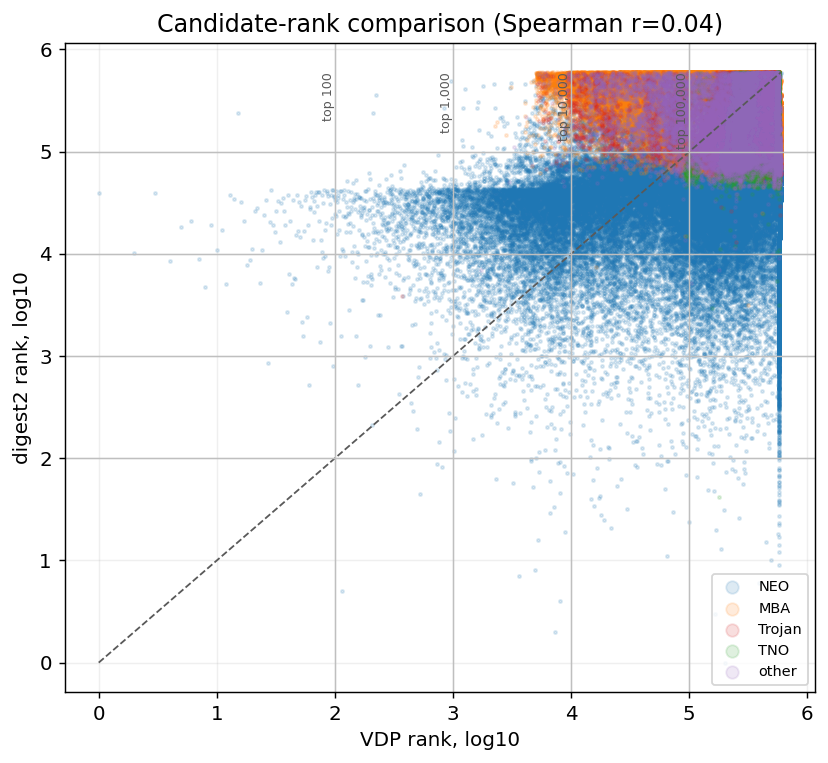

,population,P_NEO_vdp,P_NEO_d2,VDP rank,digest2 rank,vlam,vbeta,mean_mag
0,MBA,0.000229,0.01,467972,364116,-0.248413,-0.074745,23.891709
1,NEO,0.084532,1.00,201191,1,-0.515879,0.398432,20.604064
2,MBA,0.000200,0.01,481857,364117,-0.225581,0.057104,22.297899
3,MBA,0.003294,0.00,292088,507108,-0.231530,-0.043710,22.343702
4,MBA,0.000089,0.02,540579,303783,-0.225635,0.076252,21.051100


In [8]:
rank_df = df.copy()
rank_df['VDP rank']    = rank_df['P_NEO_vdp'].rank(method='first', ascending=False).astype(int)
rank_df['digest2 rank'] = rank_df['P_NEO_d2'].rank(method='first', ascending=False).astype(int)
rank_df['log VDP rank']    = np.log10(rank_df['VDP rank'])
rank_df['log digest2 rank'] = np.log10(rank_df['digest2 rank'])

spearman = rank_df[['P_NEO_vdp', 'P_NEO_d2']].corr(method='spearman').iloc[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for pop in pops:
    sub = rank_df[rank_df.population == pop]
    ax.scatter(sub['log VDP rank'], sub['log digest2 rank'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)

max_log_rank = np.log10(len(rank_df))
ax.plot([0, max_log_rank], [0, max_log_rank], color='0.35', lw=1, linestyle='--')
for n in [100, 1000, 10000, 100000]:
    if n <= len(rank_df):
        r = np.log10(n)
        ax.axvline(r, color='0.75', lw=0.8)
        ax.axhline(r, color='0.75', lw=0.8)
        ax.text(r, max_log_rank, f'top {n:,}', fontsize=7, rotation=90, va='top', ha='right', color='0.35')

ax.set_xlabel('VDP rank, log10')
ax.set_ylabel('digest2 rank, log10')
ax.set_title(f'Candidate-rank comparison (Spearman r={spearman:.2f})')
ax.legend(fontsize=8, markerscale=4, loc='lower right')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
plt.close(fig)

rank_df[['population', 'P_NEO_vdp', 'P_NEO_d2', 'VDP rank', 'digest2 rank', 'vlam', 'vbeta', 'mean_mag']].head()


## 8. Top-N follow-up yield

This is the observer-facing version of the comparison: if we can follow up only the top-ranked candidates, how many true NEOs do we recover and how contaminated is that follow-up list?

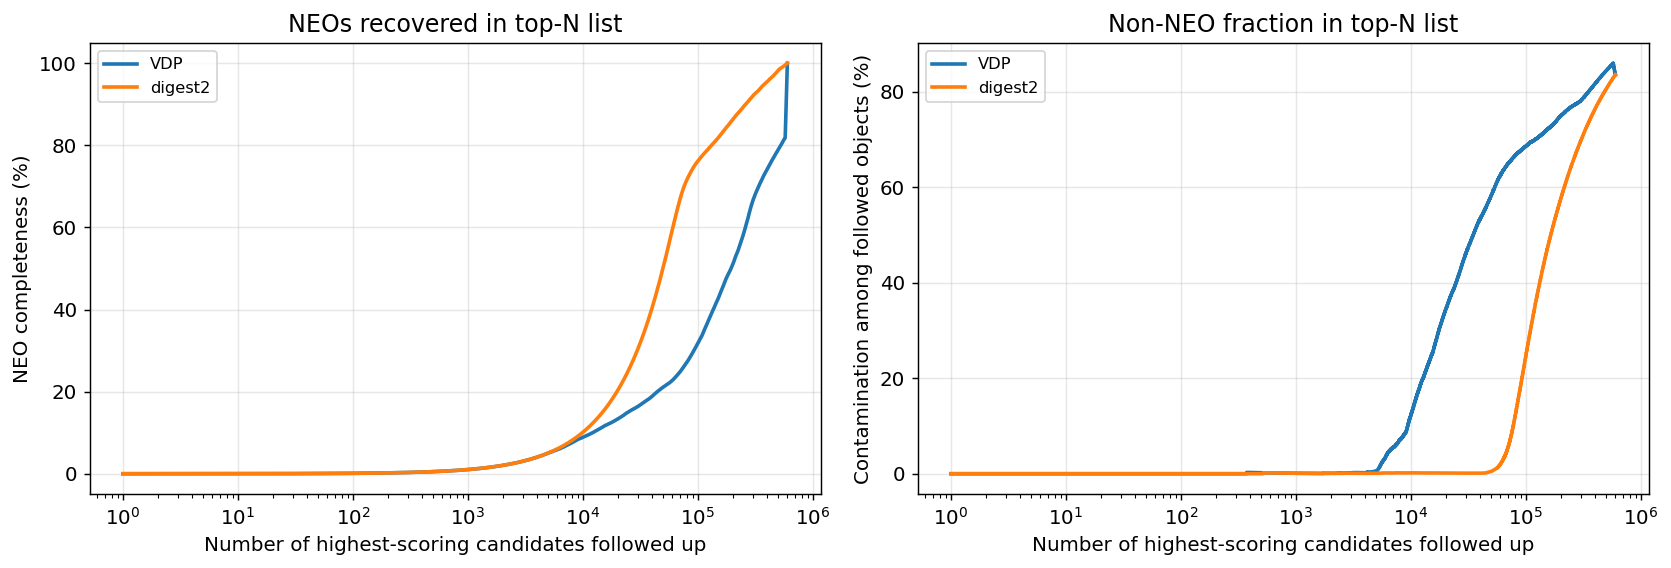

neo_recovered          completeness_pct         contamination_pct  \
classifier           VDP  digest2              VDP digest2               VDP   
n_followed                                                                     
100                100.0    100.0             0.10    0.10              0.00   
500                499.0    500.0             0.51    0.51              0.20   
1000               999.0    999.0             1.01    1.01              0.10   
5000              4973.0   4996.0             5.04    5.06              0.54   
10000             8762.0   9982.0             8.88   10.12             12.38   
50000            20847.0  49753.0            21.13   50.44             58.31   

                    
classifier digest2  
n_followed          
100           0.00  
500           0.00  
1000          0.10  
5000          0.08  
10000         0.18  
50000         0.49

In [9]:
def followup_curve(score_col, label):
    ordered = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    selected = np.arange(1, len(ordered) + 1)
    neo_cum = (ordered.population == 'NEO').cumsum().to_numpy()
    completeness  = neo_cum / N_neo
    contamination = 1 - (neo_cum / selected)
    return pd.DataFrame({
        'n_followed': selected,
        'neo_recovered': neo_cum,
        'completeness': completeness,
        'contamination': contamination,
        'classifier': label,
    })

followup = pd.concat([
    followup_curve('P_NEO_vdp', 'VDP'),
    followup_curve('P_NEO_d2',  'digest2'),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for label, color in [('VDP', 'tab:blue'), ('digest2', 'tab:orange')]:
    sub = followup[followup.classifier == label]
    axes[0].plot(sub.n_followed, sub.completeness  * 100, color=color, lw=2, label=label)
    axes[1].plot(sub.n_followed, sub.contamination * 100, color=color, lw=2, label=label)

for ax in axes:
    ax.set_xscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    ax.set_xlabel('Number of highest-scoring candidates followed up')
axes[0].set_ylabel('NEO completeness (%)')
axes[0].set_title('NEOs recovered in top-N list')
axes[1].set_ylabel('Contamination among followed objects (%)')
axes[1].set_title('Non-NEO fraction in top-N list')
plt.tight_layout()
plt.show()
plt.close(fig)

summary_n = [100, 500, 1000, 5000, 10000, 50000]
summary_n = [n for n in summary_n if n <= len(df)]
followup_summary = (
    followup[followup.n_followed.isin(summary_n)]
    .assign(completeness_pct=lambda x: x.completeness * 100,
            contamination_pct=lambda x: x.contamination * 100)
    .pivot(index='n_followed', columns='classifier', values=['neo_recovered', 'completeness_pct', 'contamination_pct'])
)
display(followup_summary.round(2))


## 10. Per-population score breakdown

In [10]:
for pop in sorted(df.population.unique()):
    sub = df[df.population == pop]
    vdp_med = sub.P_NEO_vdp.median()
    d2_med  = sub.P_NEO_d2.median()
    vdp_hi  = (sub.P_NEO_vdp > tv).mean()
    d2_hi   = (sub.P_NEO_d2  > td).mean()
    print(f'{pop:10s}  n={len(sub):6,}  '
          f'VDP median={vdp_med:.4f}  above_thr={vdp_hi:.1%}  '
          f'| d2 median={d2_med:.4f}  above_thr={d2_hi:.1%}')


MBA         n=452,304  VDP median=0.0018  above_thr=26.2%  | d2 median=0.0200  above_thr=0.6%
NEO         n=98,646  VDP median=0.1003  above_thr=47.2%  | d2 median=0.9900  above_thr=70.4%
TNO         n= 5,919  VDP median=0.0008  above_thr=5.4%  | d2 median=0.3700  above_thr=38.1%
Trojan      n=21,707  VDP median=0.0003  above_thr=11.3%  | d2 median=0.0800  above_thr=4.8%
other       n=20,094  VDP median=0.0062  above_thr=28.3%  | d2 median=0.0800  above_thr=6.8%


## 11. Explore: VDP score vs. observable properties

/tmp/ipykernel_4075487/613416858.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/mmfs1/gscratch/astro/ds2004/sorcha/conda_prep/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


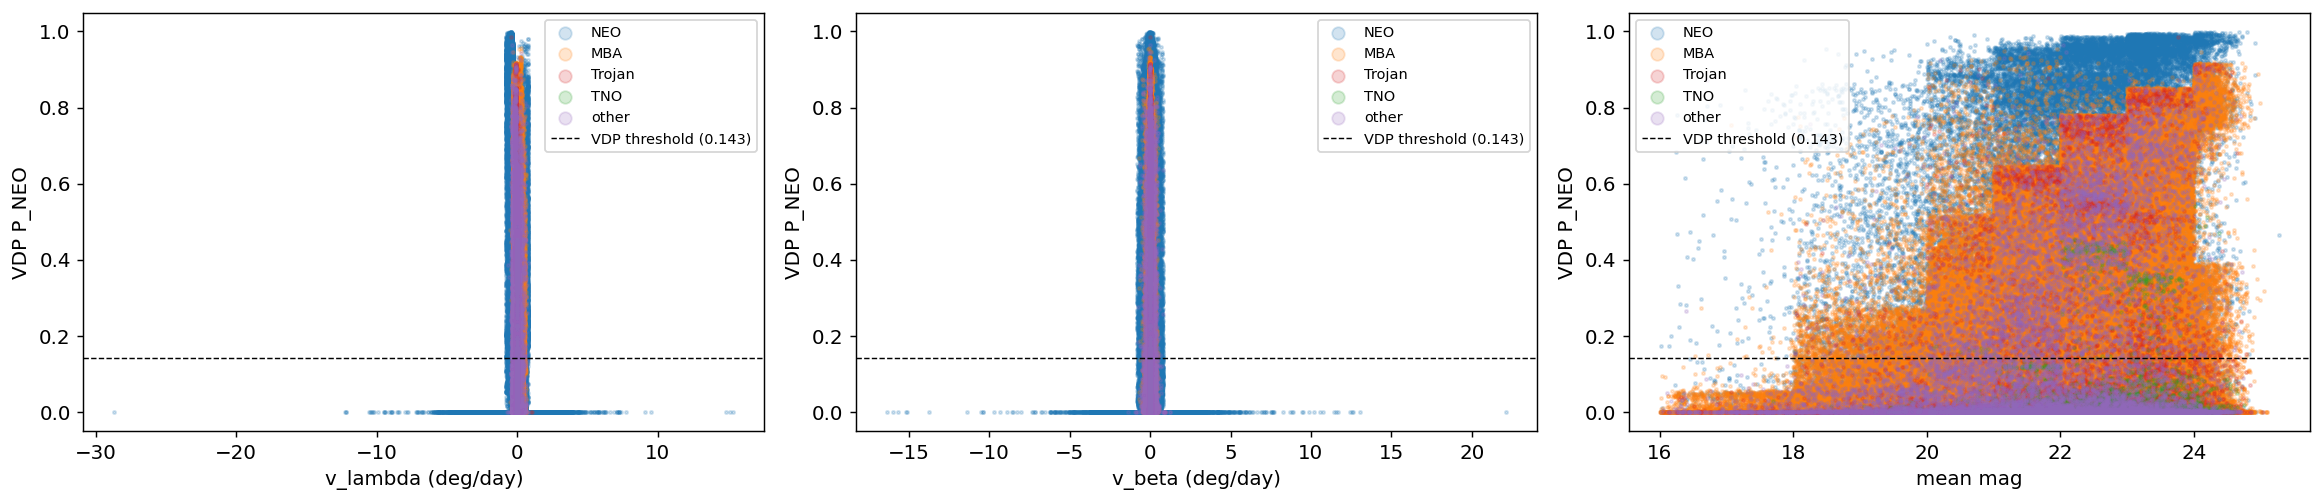

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mean_mag', 'mean mag')]
):
    for pop in pops:
        sub = df[df.population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=3, alpha=0.2,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=4)

plt.tight_layout()
plt.show()
plt.close(fig)


/tmp/ipykernel_4075487/577044324.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


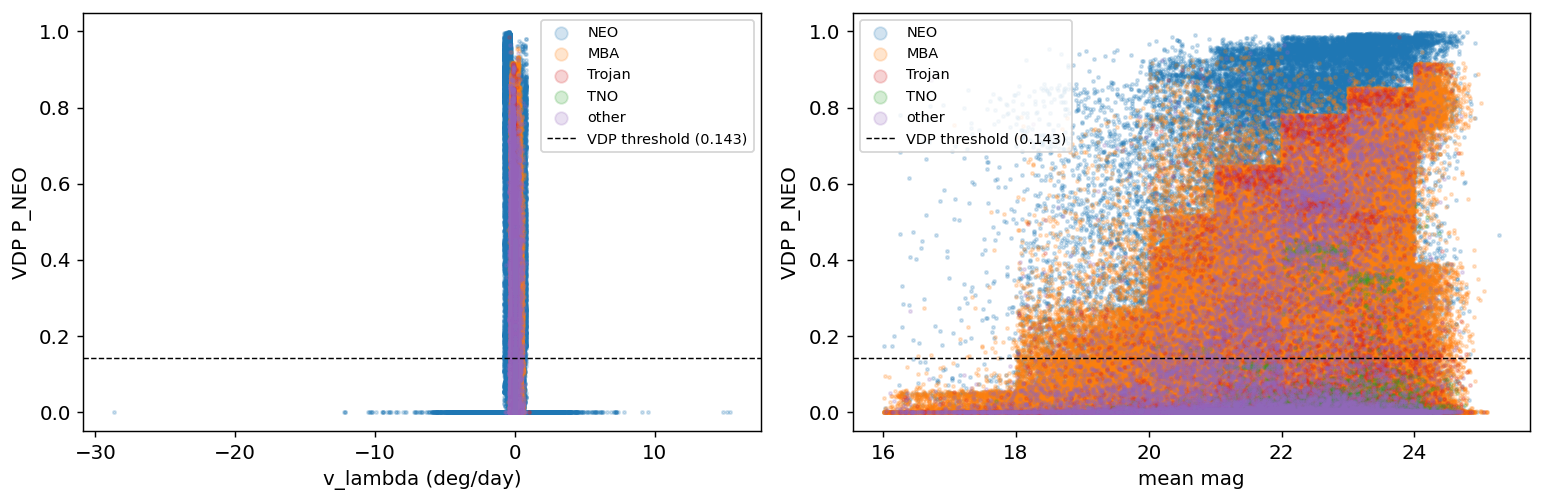

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('mean_mag', 'mean mag')]
):
    for pop in pops:
        sub = df[df.population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_vdp'], s=3, alpha=0.2,
                   label=pop, color=colors.get(pop))
    ax.axhline(tv, color='k', lw=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('VDP P_NEO')
    ax.legend(fontsize=8, markerscale=4)

plt.tight_layout()
plt.show()
plt.close(fig)


### Direct score comparison

This single-panel view puts the two classifier scores against each other for the same objects. The threshold lines mark the best-F1 operating points from the ROC section.

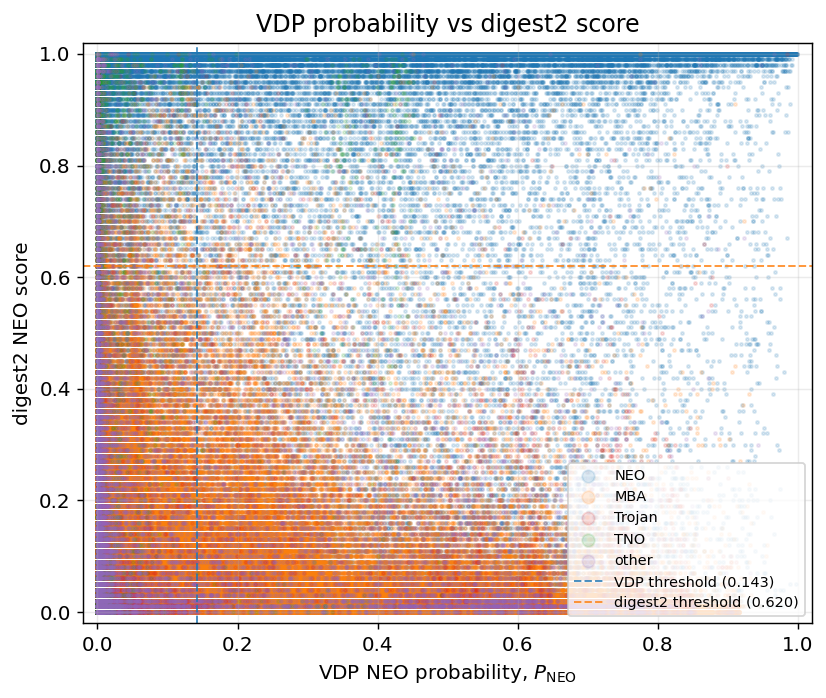

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for pop in pops:
    sub = df[df.population == pop]
    ax.scatter(sub['P_NEO_vdp'], sub['P_NEO_d2'], s=3, alpha=0.15,
               label=pop, color=colors.get(pop), rasterized=True)

ax.axvline(tv, color='tab:blue',   lw=1.1, alpha=0.8, linestyle='--', label=f'VDP threshold ({tv:.3f})')
ax.axhline(td, color='tab:orange', lw=1.1, alpha=0.8, linestyle='--', label=f'digest2 threshold ({td:.3f})')
ax.set_xlabel('VDP NEO probability, $P_{\mathrm{NEO}}$')
ax.set_ylabel('digest2 NEO score')
ax.set_title('VDP probability vs digest2 score')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, markerscale=4, loc='lower right')
plt.tight_layout()
plt.show()
plt.close(fig)


## 12. Explore: digest2 score vs. observable properties

/tmp/ipykernel_4075487/1238592369.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


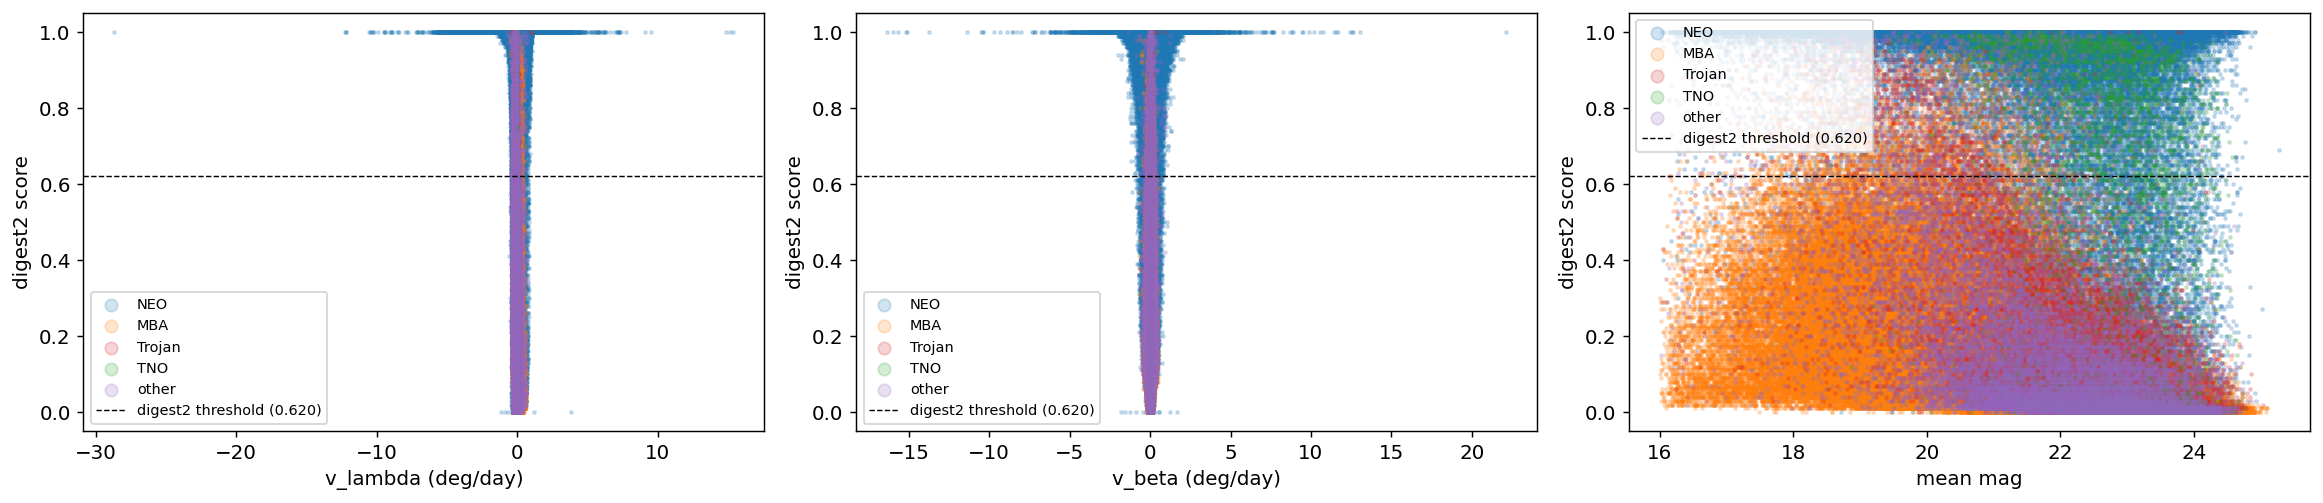

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (xcol, xlabel) in zip(
    axes,
    [('vlam', 'v_lambda (deg/day)'), ('vbeta', 'v_beta (deg/day)'), ('mean_mag', 'mean mag')]
):
    for pop in pops:
        sub = df[df.population == pop]
        ax.scatter(sub[xcol], sub['P_NEO_d2'], s=3, alpha=0.2,
                   label=pop, color=colors.get(pop))
    ax.axhline(td, color='k', lw=0.8, linestyle='--', label=f'digest2 threshold ({td:.3f})')
    ax.set_xlabel(xlabel); ax.set_ylabel('digest2 score')
    ax.legend(fontsize=8, markerscale=4)

plt.tight_layout()
plt.show()
plt.close(fig)


## 13. Epoch-matched ROC comparison

VDP maps encode velocity statistics at a **specific epoch** (specific solar elongation geometry).
Tracklets observed close in time to their map's epoch have the right geometry;
those from other months don't — the Sun has moved, so the antisun direction has shifted,
and NEO/MBA velocity signatures are different.

**Filter**: keep only tracklets within ±30 days of their assigned map's canonical epoch.
- `lon180_lat0` map (built 2025-03-21) → use March 2026 window (same solar geometry; simulation starts May 2025)
- `lon229_lat0` / `antisun_*` maps (built 2026-05-09) → use May 2026 ±30d AND May 2025 ±30d


In [ ]:
from astropy.time import Time

# Canonical epoch for each map (MJD), accounting for annual repeat
_epoch_primary = {
    "2025-03-21T00:00:00": Time("2026-03-21").mjd,        # annual repeat; sim starts May 2025
    "2026-05-09T00:00:00": Time("2026-05-09").mjd,
    "2026-05-09T22:00:00": Time("2026-05-09T22:00:00").mjd,
}
_epoch_prev = {                                            # one year earlier (May maps only)
    "2026-05-09T00:00:00": Time("2025-05-09").mjd,
    "2026-05-09T22:00:00": Time("2025-05-09T22:00:00").mjd,
}
EPOCH_WINDOW = 30  # days

e1   = df["prob_map_obstime_str"].map(_epoch_primary)
e2   = df["prob_map_obstime_str"].map(_epoch_prev).fillna(np.inf)
emask = (np.abs(df.mjd0_utc - e1) <= EPOCH_WINDOW) | (np.abs(df.mjd0_utc - e2) <= EPOCH_WINDOW)
df_ep = df[emask].copy()

is_neo_ep = (df_ep.population == "NEO").to_numpy()
N_neo_ep  = is_neo_ep.sum()
print(f"Epoch-matched: {len(df_ep):,} tracklets ({len(df_ep)/len(df):.1%} of full subsample)")
print(f"NEOs: {N_neo_ep:,} ({is_neo_ep.mean():.1%})")
print(f"\nPer map:")
for m, g in df_ep.groupby("prob_map"):
    n = (g.population=="NEO").sum()
    print(f"  {m:35s}  {len(g):6,} total  {n:5,} NEOs")


In [ ]:
comp_v_ep, cont_v_ep = compute_roc(df_ep.P_NEO_vdp.to_numpy(), is_neo_ep, thresholds)
comp_d_ep, cont_d_ep = compute_roc(df_ep.P_NEO_d2.to_numpy(),  is_neo_ep, thresholds)

tv_ep, cv_ep, nv_ep, fv_ep = best_f1(comp_v_ep, cont_v_ep, thresholds)
td_ep, cd_ep, nd_ep, fd_ep = best_f1(comp_d_ep, cont_d_ep, thresholds)

rows = [
    ("All tracklets (598K)", "VDP",     fv,    cv,    nv,    tv),
    ("All tracklets (598K)", "digest2", fd,    cd,    nd,    td),
    ("Epoch-matched (137K)", "VDP",     fv_ep, cv_ep, nv_ep, tv_ep),
    ("Epoch-matched (137K)", "digest2", fd_ep, cd_ep, nd_ep, td_ep),
]
print(f"  {'Dataset':33s}  {'Clf':8s}  {'F1':>6}  {'Comp':>7}  {'Cont':>7}  {'Thr':>6}")
print("  " + "-" * 72)
for label, clf, f, c, n, t in rows:
    print(f"  {label:33s}  {clf:8s}  {f:.3f}  {c:6.1%}  {n:6.1%}  {t:.3f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (comp_v_, cont_v_, comp_d_, cont_d_, tv_, cv_, nv_, fv_, td_, cd_, nd_, fd_, title) in zip(axes, [
    (comp_v,    cont_v,    comp_d,    cont_d,    tv,    cv,    nv,    fv,    td,    cd,    nd,    fd,    "All tracklets (598K)"),
    (comp_v_ep, cont_v_ep, comp_d_ep, cont_d_ep, tv_ep, cv_ep, nv_ep, fv_ep, td_ep, cd_ep, nd_ep, fd_ep, "Epoch-matched (137K, ±30d)"),
]):
    ax.plot(comp_v_*100, cont_v_*100, lw=2.2, color='tab:blue',   label='VDP')
    ax.plot(comp_d_*100, cont_d_*100, lw=2.2, color='tab:orange', linestyle='--', label='digest2')
    ax.scatter([cv_*100], [nv_*100], color='tab:blue',   s=100, zorder=5, label=f'VDP best F1={fv_:.3f}')
    ax.scatter([cd_*100], [nd_*100], color='tab:orange', s=100, zorder=5, marker='s', label=f'd2 best F1={fd_:.3f}')
    ax.annotate(f't={tv_:.3f}', xy=(cv_*100, nv_*100), xytext=(6, 6),  textcoords='offset points', color='tab:blue',   fontsize=8)
    ax.annotate(f't={td_:.3f}', xy=(cd_*100, nd_*100), xytext=(6, -12), textcoords='offset points', color='tab:orange', fontsize=8)
    ax.set_xlabel('NEO completeness (%)')
    ax.set_ylabel('Contamination (%)')
    ax.set_title(f'ROC — {title}', fontsize=10)
    ax.legend(fontsize=9, frameon=True, loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIG_OUT.replace('.png', '_epoch_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)


In [ ]:
# Per-map F1 on epoch-matched tracklets
print(f"  {'Map':35s}  {'n_NEO':>6}  {'VDP F1':>7}  {'d2 F1':>7}")
print("  " + "-" * 60)
for m, g in df_ep.groupby("prob_map"):
    gn = (g.population == "NEO").to_numpy()
    if gn.sum() < 10:
        continue
    c_v, ct_v = compute_roc(g.P_NEO_vdp.to_numpy(), gn, thresholds)
    c_d, ct_d = compute_roc(g.P_NEO_d2.to_numpy(),  gn, thresholds)
    _, _, _, fv_m = best_f1(c_v, ct_v, thresholds)
    _, _, _, fd_m = best_f1(c_d, ct_d, thresholds)
    print(f"  {m:35s}  {gn.sum():6,}  {fv_m:7.3f}  {fd_m:7.3f}")
